# Benchmark - Anthropic's Claude Opus 5

**Date:** 12-13 Aug 2026

**Evaluation:** Tasks 01-07

**Hardware** RTX 4070 SUPER

In [13]:
import json
import re
import shutil
import textwrap

import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath
from scipy.stats import mannwhitneyu, wilcoxon, false_discovery_control

BASE_DIR = Path.cwd()
TEST_DIR = BASE_DIR.parent / "test"
DATA_DIR = BASE_DIR.parent / "data"
HARDWARE = "RTX 4070 SUPER"
RUNS_PER_BATCH = 5

SURFACE = "#fcfcfb"
SERIES = {False: ("#eb6834", "No skills"), True: ("#2a78d6", "Skills")}


In [14]:
TOKEN_FIELDS = {  # column name -> key in run.jsonl's usage object
  "input_tokens": "input",
  "output_tokens": "output",
  "cache_read_tokens": "cacheRead",
  "cache_write_tokens": "cacheWrite",
  "total_tokens": "totalTokens",
}

def count_tokens(run_dir: Path) -> dict[str, int | None]:
  events_file = run_dir / "run.jsonl"
  if not events_file.exists():
    return {column: None for column in TOKEN_FIELDS}

  totals = {column: 0 for column in TOKEN_FIELDS}
  for line in events_file.open(encoding="utf-8", errors="replace"):
    line = line.strip()
    if not line.startswith("{"):  # the container logs boot noise before the event stream
      continue
    try:
      event = json.loads(line)
    except json.JSONDecodeError:  # a killed container can leave a half-written line
      continue
    if event.get("type") == "message_end":  # usage is per API call, so sum over the run
      usage = event.get("message", {}).get("usage") or {}
      for column, key in TOKEN_FIELDS.items():
        totals[column] += usage.get(key) or 0
  return totals

def add_token_counts(runs: pd.DataFrame, test_dir: Path = TEST_DIR) -> pd.DataFrame:
  # run.jsonl is the big file in a run dir, so only read it for the runs we keep
  counts = [count_tokens(test_dir / row.task / "runs" / row.run) for row in runs.itertuples()]
  return runs.join(pd.DataFrame(counts, index=runs.index))

def load_runs(test_dir: Path = TEST_DIR) -> pd.DataFrame:
  rows = []
  for runs_dir in sorted(test_dir.glob("*/runs")):
    for run_dir in sorted(p for p in runs_dir.iterdir() if p.is_dir()):
      result_file = run_dir / "eval_result.json"
      if not result_file.exists():
        print(f"Skipping {run_dir} because {result_file} does not exist")
        continue
      r = json.loads(result_file.read_text())
      rows.append(
        {
          "task": runs_dir.parent.name,
          "run": run_dir.name,
          "start_time": pd.to_datetime(r.get("start_time")),
          "skills": r["skills"],
          "score": r["score"],
          "points": r["points"],
          "total": r["total"],
          "passed": r["passed"],
          "structure_match": r.get("structure_match"),
          "duration_seconds": r["duration_seconds"],
          "timed_out": r.get("timed_out", False),
          "interrupted": r.get("interrupted", False),
          "model": r.get("model"),
          "harness": r.get("harness"),
          "model_server": r.get("model_server"),
          "hardware": HARDWARE,
          "fields": r.get("fields", {}),
        }
      )
  return pd.DataFrame(rows)

def latest_batches(runs: pd.DataFrame, n: int = RUNS_PER_BATCH) -> pd.DataFrame:
  # start_time is absent on pre-2026-08-11 runs; those are the oldest, so NaT sorts first
  ordered = runs.sort_values(["task", "skills", "start_time"], na_position="first")
  return ordered.groupby(["task", "skills"], as_index=False).tail(n).reset_index(drop=True)

# test.py passes ANTHROPIC_API_KEY into the container and pi echoes the environment
# into run.jsonl/run.txt, so the copy has to be scrubbed before anything is committed.
SECRET_PATTERN = re.compile(rb"sk-ant-[A-Za-z0-9_-]{20,}")
SECRET_REPLACEMENT = b"sk-ant-***REDACTED***"

def mask_secrets(run_dir: Path) -> int:
  masked = 0
  for file in run_dir.rglob("*"):
    if not file.is_file():
      continue
    raw = file.read_bytes()
    scrubbed, hits = SECRET_PATTERN.subn(SECRET_REPLACEMENT, raw)
    if hits:
      file.write_bytes(scrubbed)
      masked += hits
  return masked

def save_runs(
  runs: pd.DataFrame,
  dir: Path,
  test_dir: Path = TEST_DIR,
  exclude: tuple[str, ...] = (),
  force: bool = False,
) -> None:
  dir.mkdir(parents=True, exist_ok=True)
  runs.to_csv(dir / "benchmark.csv", index=False)

  ignore = shutil.ignore_patterns(*exclude) if exclude else None
  copied = masked = 0
  for row in runs.itertuples():
    src = test_dir / row.task / "runs" / row.run
    dst = dir / "runs" / row.task / row.run
    if dst.exists():
      if not force:  # run dirs never change once graded
        continue
      shutil.rmtree(dst)
    shutil.copytree(src, dst, ignore=ignore)
    masked += mask_secrets(dst)
    copied += 1

  print(f"{dir / 'benchmark.csv'}: {len(runs)} rows")
  print(f"{dir / 'runs'}: copied {copied}, already present {len(runs) - copied}")
  print(f"masked {masked} credential(s) in the copied logs")


In [15]:
benchmark_dir = DATA_DIR / "anthropic" / "claude-opus-5"

if (not benchmark_dir.exists()):
  all_runs = load_runs()
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir)


In [16]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260812_181745_1,2026-08-12 18:17:45.782456,False,1.0,5,5,True,True,83,...,claude-opus-5,pi,anthropic,RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",22,3601,52385,7622,63630
1,01-data-loading,20260812_181909_2,2026-08-12 18:19:09.765633,False,1.0,5,5,True,True,107,...,claude-opus-5,pi,anthropic,RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",20,5513,61546,8440,75519
2,01-data-loading,20260812_182057_3,2026-08-12 18:20:57.198450,False,1.0,5,5,True,True,89,...,claude-opus-5,pi,anthropic,RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",16,3456,36620,4991,45083
3,01-data-loading,20260812_182226_4,2026-08-12 18:22:26.465600,False,1.0,5,5,True,True,84,...,claude-opus-5,pi,anthropic,RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",18,3432,42311,5032,50793
4,01-data-loading,20260812_182350_5,2026-08-12 18:23:50.906132,False,1.0,5,5,True,True,81,...,claude-opus-5,pi,anthropic,RTX 4070 SUPER,"{'n_cells': {'expected': 20857, 'actual': 2085...",22,3145,53861,5301,62329


In [ ]:
MIN_BOX_FRACTION = 0.05  # of the y-range, so a zero-spread batch reads as a box in any unit
COLUMN_LABELS = {
  "score": "Score",
  "total_tokens": "Total tokens",
  "duration_seconds": "Duration (s)",
}
# only the per-task boxplots rescale; (divisor, unit shown in the axis label)
COLUMN_SCALES = {"total_tokens": (1e6, "M")}

def plot_benchmark(runs: pd.DataFrame, column: str, ax=None, points: bool = True):
  scale, unit = COLUMN_SCALES.get(column, (1.0, None))
  runs = runs.assign(**{column: runs[column] / scale})
  tasks = sorted(runs["task"].unique())
  pos = {task: i for i, task in enumerate(tasks)}
  if ax is None:
    _, ax = plt.subplots(figsize=(11, 5.5))

  values = runs[column].astype(float)
  low, high = min(0.0, values.min()), values.max()
  pad = 0.05 * (high - low or 1.0)
  ylim = (low - pad, high + pad)
  min_box = MIN_BOX_FRACTION * (ylim[1] - ylim[0])

  for skills, (color, _) in SERIES.items():
    offset = 0.19 if skills else -0.19
    batches = {task: batch for task, batch in runs[runs["skills"] == skills].groupby("task")}
    present = [t for t in tasks if t in batches]
    bp = ax.boxplot(
      [batches[t][column].values for t in present],
      positions=[pos[t] + offset for t in present],
      widths=0.3, patch_artist=True, manage_ticks=False, zorder=2,
      whis=(0, 100), showfliers=False,  # n = 5; 1.5*IQR would call most points outliers
      showmeans=True, meanline=True,
      boxprops=dict(facecolor=color + "38", edgecolor=color, linewidth=1.2),  # 38 = ~22% alpha
      medianprops=dict(linewidth=0),
      meanprops=dict(color=color, linewidth=2, linestyle="-"),
      whiskerprops=dict(color=color, linewidth=1.2),
      capprops=dict(color=color, linewidth=1.2),
    )

    for box in bp["boxes"]:  # redraw boxes that collapsed to a line (IQR of 0)
      verts = box.get_path().vertices
      lo, hi = verts[:, 1].min(), verts[:, 1].max()
      if hi - lo < min_box:
        x0, x1 = verts[:, 0].min(), verts[:, 0].max()
        mid = (lo + hi) / 2
        bottom, top = mid - min_box / 2, mid + min_box / 2
        box.set_path(
          MplPath([(x0, bottom), (x1, bottom), (x1, top), (x0, top), (x0, bottom)], closed=True)
        )

    if points:  # n = 5, so show the runs the box is drawn from
      for task, batch in batches.items():
        spread = np.linspace(-0.07, 0.07, len(batch))
        ax.scatter(
          pos[task] + offset + spread, batch[column],
          s=22, color=color, edgecolor=SURFACE, linewidth=0.8, alpha=0.75, zorder=3,
        )

  label = COLUMN_LABELS.get(column, column.replace("_", " ").capitalize())
  if unit:
    label = f"{label} ({unit})"
  ax.set_xticks(range(len(tasks)))
  ax.set_xticklabels(
    [f'{t.split("-")[0]}\n' + textwrap.fill(t.split("-", 1)[1], 12) for t in tasks], fontsize=9
  )
  ax.set_xlim(-0.6, len(tasks) - 0.4)
  ax.set_ylim(*ylim)
  if column == "score":
    ax.set_yticks(np.arange(0, 1.01, 0.25))
  else:
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.2f}" if unit else f"{v:,.0f}")
  ax.set_ylabel(label)
  ax.set_title(  # only the first letter, so a unit like (M) keeps its case
    f"Claude Opus 5 — {label[0].lower() + label[1:]} per task, with and without skills",
    loc="left", pad=18,
  )
  ax.text(
    0, 1.02,
    f"{RUNS_PER_BATCH} runs per box; box = IQR, whiskers = min-max, bar = mean, dots = individual runs",
    transform=ax.transAxes, ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
  ax.set_axisbelow(True)
  for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
  ax.spines["bottom"].set_color("#c3c2b7")
  ax.tick_params(length=0)
  ax.legend(
    handles=[
      Patch(facecolor=color + "38", edgecolor=color, linewidth=1.2, label=series_label)
      for color, series_label in SERIES.values()
    ],
    frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0), ncol=2,
  )
  return ax

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", ax=axs[2])
fig.tight_layout()
plt.show()


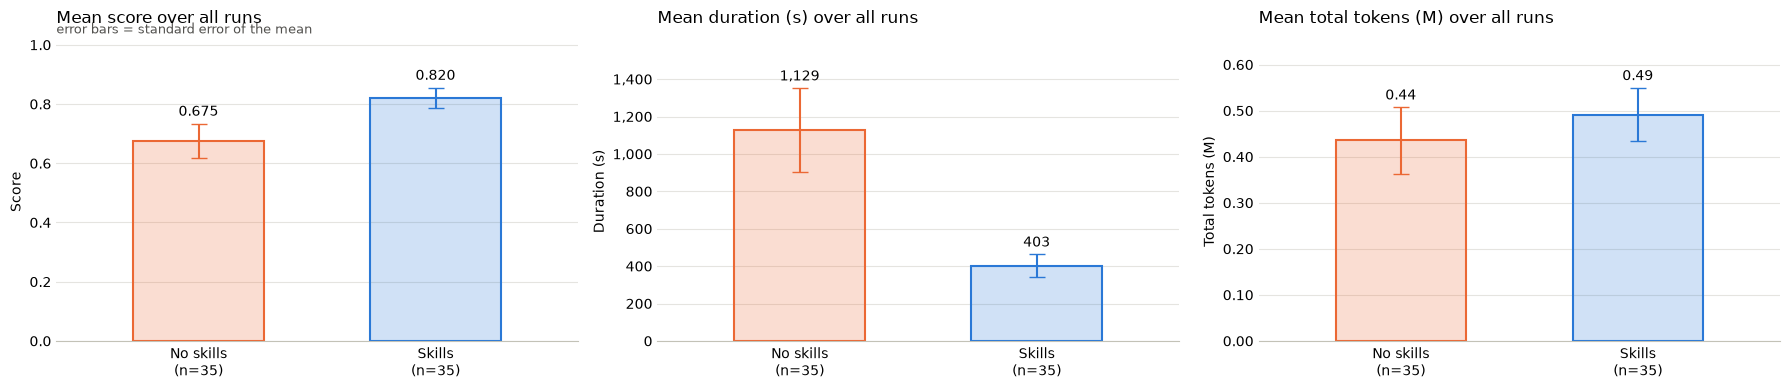

In [18]:
SUMMARY_METRICS = ("score", "duration_seconds", "total_tokens")
VALUE_FORMATS = {"score": "{:.3f}", "duration_seconds": "{:,.0f}", "total_tokens": "{:.2f}"}

def plot_skill_summary(runs: pd.DataFrame, metrics=SUMMARY_METRICS, axs=None):
  if axs is None:
    _, axs = plt.subplots(nrows=len(metrics), ncols=1, figsize=(6, 3.4 * len(metrics)))
  axs = np.ravel(axs)
  order = [False, True]

  for ax, metric in zip(axs, metrics):
    scaled = runs[metric] / COLUMN_SCALES.get(metric, 1.0)  # same units as the per-task plots
    stats = scaled.groupby(runs["skills"]).agg(["mean", "sem", "size"])
    means = [stats.loc[skills, "mean"] for skills in order]
    errors = [stats.loc[skills, "sem"] for skills in order]

    for x, skills in enumerate(order):  # one call per bar: ecolor takes a single color
      color = SERIES[skills][0]
      ax.bar(
        x, stats.loc[skills, "mean"], yerr=stats.loc[skills, "sem"], width=0.55,
        color=color + "38", edgecolor=color, linewidth=1.5, ecolor=color, capsize=6, zorder=2,
      )

    value_format = VALUE_FORMATS.get(metric, "{:,.0f}")
    for x, (mean, error) in enumerate(zip(means, errors)):
      ax.text(
        x, mean + error + 0.02 * max(means), value_format.format(mean),
        ha="center", va="bottom", fontsize=10,
      )

    label = COLUMN_LABELS.get(metric, metric.replace("_", " ").capitalize())
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{SERIES[s][1]}\n(n={stats.loc[s, 'size']:.0f})" for s in order])
    ax.set_xlim(-0.6, len(order) - 0.4)
    ax.set_ylim(0, max(m + e for m, e in zip(means, errors)) * 1.18)
    ax.set_ylabel(label)
    ax.set_title(f"Mean {label[0].lower() + label[1:]} over all runs", loc="left", pad=14)
    if metric != "score":
      ax.yaxis.set_major_formatter(COLUMN_TICK_FORMATS.get(metric, lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
      ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(length=0)

  axs[0].text(
    0, 1.02, "error bars = standard error of the mean", transform=axs[0].transAxes,
    ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  return axs

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [19]:
def compare_skills(runs: pd.DataFrame, metrics=SUMMARY_METRICS) -> pd.DataFrame:
  rows = []
  for metric in metrics:
    for scope, data in [("all tasks (pooled)", runs)] + list(runs.groupby("task")):
      without = data.loc[~data["skills"], metric].astype(float)
      with_skills = data.loc[data["skills"], metric].astype(float)
      if np.ptp(np.concatenate([without, with_skills])) == 0:
        p = 1.0  # every run identical: U is undefined, and there is nothing to detect
      else:
        _, p = mannwhitneyu(with_skills, without, alternative="two-sided")
      rows.append(
        {
          "metric": metric, "scope": scope, "test": "Mann-Whitney U",
          "n": f"{len(without)} vs {len(with_skills)}",
          "mean_no_skills": without.mean(), "mean_skills": with_skills.mean(),
          "diff": with_skills.mean() - without.mean(), "p_value": p,
        }
      )

    # paired alternative: one mean per task, so task difficulty cancels out
    task_means = runs.groupby(["task", "skills"])[metric].mean().unstack()
    _, p = wilcoxon(task_means[True], task_means[False])
    rows.append(
      {
        "metric": metric, "scope": "all tasks (paired by task)", "test": "Wilcoxon signed-rank",
        "n": f"{len(task_means)} tasks",
        "mean_no_skills": task_means[False].mean(), "mean_skills": task_means[True].mean(),
        "diff": (task_means[True] - task_means[False]).mean(), "p_value": p,
      }
    )

  results = pd.DataFrame(rows)
  results["p_fdr"] = np.nan
  per_task = ~results["scope"].str.startswith("all tasks")
  for metric in metrics:  # Benjamini-Hochberg within each metric's family of 7 per-task tests
    family = per_task & (results["metric"] == metric)
    results.loc[family, "p_fdr"] = false_discovery_control(results.loc[family, "p_value"], method="bh")
  results["significant_fdr"] = results["p_fdr"] < 0.05
  return results

def metric_table(metric: str) -> pd.DataFrame:
  return significance[significance["metric"] == metric].drop(columns="metric").reset_index(drop=True)

significance = compare_skills(benchmark)


In [20]:
metric_table("score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,0.674603,0.819683,0.145079,0.122683,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1.000000,1.000000,0.000000,1.000000,1.000000,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.700000,1.000000,0.300000,0.024251,0.084880,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,0.822222,0.911111,0.088889,0.217154,0.380020,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,1.000000,1.000000,0.000000,1.000000,1.000000,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.760000,0.640000,-0.120000,0.312619,0.437666,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.240000,0.520000,0.280000,0.062567,0.145989,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,0.200000,0.666667,0.466667,0.006502,0.045512,True
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,0.674603,0.819683,0.145079,0.187500,NaN,False


In [21]:
metric_table("duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,1129.142857,403.142857,-726.0,0.163901,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,88.800000,61.400000,-27.4,0.011925,0.027826,True
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,129.000000,141.600000,12.6,0.150794,0.211111,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,631.200000,400.800000,-230.4,0.150794,0.211111,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,168.400000,175.200000,6.8,1.000000,1.000000,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,823.200000,372.800000,-450.4,0.222222,0.259259,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,3067.200000,1123.800000,-1943.4,0.011925,0.027826,True
7,07-epitope-databases,Mann-Whitney U,5 vs 5,2996.200000,546.400000,-2449.8,0.011925,0.027826,True
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,1129.142857,403.142857,-726.0,0.078125,NaN,False


In [22]:
metric_table("total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,4.351960e+05,4.911535e+05,55957.485714,0.169351,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,5.947080e+04,7.202340e+04,12552.600000,0.055556,0.129630,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,7.030840e+04,2.350168e+05,164708.400000,0.007937,0.027778,True
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,6.696960e+05,7.505576e+05,80861.600000,0.309524,0.309524,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,1.441112e+05,2.910730e+05,146961.800000,0.007937,0.027778,True
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,3.551370e+05,5.044584e+05,149321.400000,0.095238,0.133333,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,7.023152e+05,1.072821e+06,370505.400000,0.095238,0.133333,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,1.045334e+06,5.121248e+05,-533208.800000,0.150794,0.175926,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,4.351960e+05,4.911535e+05,55957.485714,0.296875,NaN,False


In [23]:
PRICES_USD_PER_MTOK = {  # Claude Opus 5, USD per million tokens
  "input_tokens": 5.00,
  "cache_write_tokens": 6.25,  # 5-minute TTL; no run used the 1h cache ($10)
  "cache_read_tokens": 0.50,
  "output_tokens": 25.00,
}

def add_cost(runs: pd.DataFrame) -> pd.DataFrame:
  cost = sum(runs[column] * price for column, price in PRICES_USD_PER_MTOK.items()) / 1e6
  return runs.assign(cost_usd=cost)

priced = add_cost(benchmark)


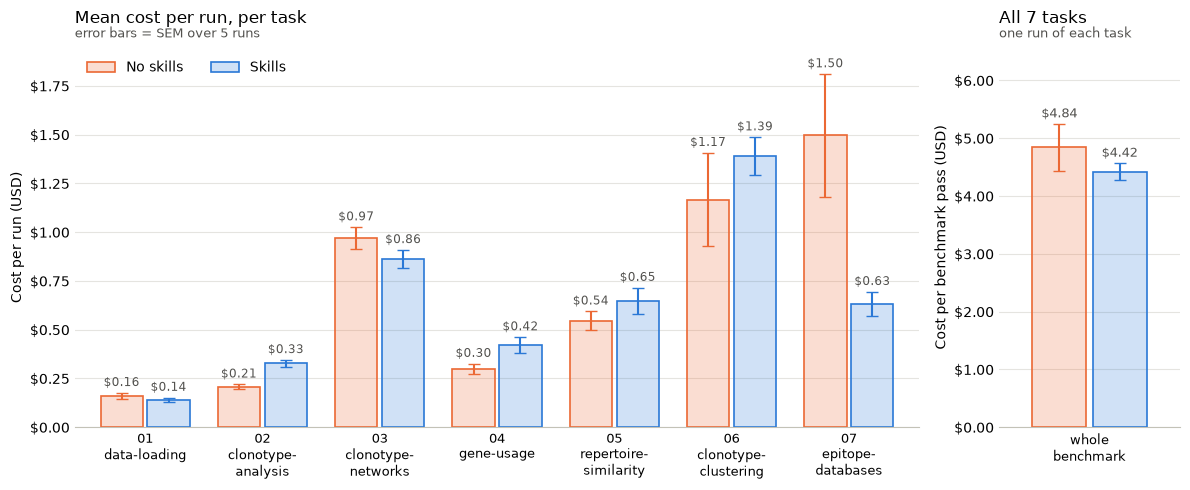

In [24]:
def style_cost_axis(ax):
  ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
  ax.set_axisbelow(True)
  for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
  ax.spines["bottom"].set_color("#c3c2b7")
  ax.tick_params(length=0)
  ax.yaxis.set_major_formatter(lambda v, _: f"\\${v:,.2f}")  # \$ is not mathtext

def plot_cost(runs: pd.DataFrame, axs=None):
  tasks = sorted(runs["task"].unique())
  if axs is None:
    _, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
  task_ax, benchmark_ax = axs
  pass_costs, pass_errors = [], []

  for skills, (color, _) in SERIES.items():
    arm = runs[runs["skills"] == skills]
    stats = arm.groupby("task")["cost_usd"].agg(["mean", "sem"]).reindex(tasks)
    xs = [i + (0.2 if skills else -0.2) for i in range(len(tasks))]
    task_ax.bar(
      xs, stats["mean"], yerr=stats["sem"], width=0.36, color=color + "38",
      edgecolor=color, linewidth=1.2, ecolor=color, capsize=4, zorder=2,
    )
    for x, mean, error in zip(xs, stats["mean"], stats["sem"]):
      task_ax.text(
        x, mean + error + 0.02, f"\\${mean:.2f}",
        ha="center", va="bottom", fontsize=8.5, color="#52514e",
      )

    # a benchmark pass is one run of each task, so sum the per-task means;
    # tasks are independent runs, so their standard errors add in quadrature
    pass_cost = stats["mean"].sum()
    pass_error = np.sqrt((stats["sem"] ** 2).sum())
    pass_costs.append(pass_cost)
    pass_errors.append(pass_error)
    x = 0.2 if skills else -0.2
    benchmark_ax.bar(
      x, pass_cost, yerr=pass_error, width=0.36, color=color + "38",
      edgecolor=color, linewidth=1.2, ecolor=color, capsize=4, zorder=2,
    )
    benchmark_ax.text(
      x, pass_cost + pass_error + 0.06, f"\\${pass_cost:.2f}",
      ha="center", va="bottom", fontsize=9, color="#52514e",
    )

  task_ax.set_xticks(range(len(tasks)))
  task_ax.set_xticklabels(
    [f'{t.split("-")[0]}\n' + textwrap.fill(t.split("-", 1)[1], 12) for t in tasks], fontsize=9
  )
  task_ax.set_xlim(-0.6, len(tasks) - 0.4)
  task_ax.set_ylim(0, runs.groupby(["task", "skills"])["cost_usd"].mean().max() * 1.3)
  task_ax.set_ylabel("Cost per run (USD)")
  task_ax.set_title("Mean cost per run, per task", loc="left", pad=18)
  task_ax.text(
    0, 1.02, f"error bars = SEM over {RUNS_PER_BATCH} runs", transform=task_ax.transAxes,
    ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  task_ax.legend(
    handles=[
      Patch(facecolor=color + "38", edgecolor=color, linewidth=1.2, label=label)
      for color, label in SERIES.values()
    ],
    frameon=False, loc="upper left", ncol=2,
  )
  style_cost_axis(task_ax)

  benchmark_ax.set_xticks([0])
  benchmark_ax.set_xticklabels(["whole\nbenchmark"], fontsize=9)
  benchmark_ax.set_xlim(-0.6, 0.6)
  benchmark_ax.set_ylim(0, max(c + e for c, e in zip(pass_costs, pass_errors)) * 1.25)
  benchmark_ax.set_ylabel("Cost per benchmark pass (USD)")
  benchmark_ax.set_title(f"All {len(tasks)} tasks", loc="left", pad=18)
  benchmark_ax.text(
    0, 1.02, "one run of each task", transform=benchmark_ax.transAxes,
    ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  style_cost_axis(benchmark_ax)
  return axs

fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_cost(priced, axs=axs)
fig.tight_layout()
plt.show()
